# FLAIR Toy Dataset EDA


In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation

Mounted at /content/drive
/content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation


In [2]:
from collections import Counter, defaultdict
from pathlib import Path
import csv
import json

import numpy as np
from PIL import Image

# from flair website
class_names = {
    1: "building",
    2: "pervious surface",
    3: "impervious surface",
    4: "bare soil",
    5: "water",
    6: "coniferous",
    7: "deciduous",
    8: "brushwood",
    9: "vineyard",
    10: "herbaceous vegetation",
    11: "agricultural land",
    12: "plowed land",
    13: "swimming pool",
    14: "snow",
    15: "clear cut",
    16: "mixed",
    17: "ligneous",
    18: "greenhouse",
    19: "other",
}

# get repo root + dataset paths
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
dataset_root = repo_root / "data" / "raw" / "flair_1_toy_dataset" / "flair_1_toy_dataset"
csv_dir = dataset_root / "CSVs"

# load CSV records
records = []
for csv_path in sorted(csv_dir.glob("*.csv")):
    split = csv_path.stem.removeprefix("flair-1-paths-toy-")
    with csv_path.open(newline="") as file:
        for image_rel, mask_rel in csv.reader(file):
            records.append({
                "split": split,
                "image_path": (csv_path.parent / image_rel).resolve(),
                "mask_path": (csv_path.parent / mask_rel).resolve(),
            })

len(records), dataset_root


(250,
 PosixPath('/content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation/data/raw/flair_1_toy_dataset/flair_1_toy_dataset'))

In [3]:
# show split sizes, confirm  masks load as 2D label arrays
split_counts = Counter(record["split"] for record in records)
print("Samples by split")
for split, count in sorted(split_counts.items()):
    print(f"{split:>5}: {count}")

first_mask = np.array(Image.open(records[0]["mask_path"]))
print(f"Mask shape: {first_mask.shape}")
print(f"Mask dtype: {first_mask.dtype}")


Samples by split
 test: 50
train: 156
  val: 44
Mask shape: (512, 512)
Mask dtype: uint8


In [4]:

# set up counters for class pixel counts, mask counts, and split pixel counts
pixel_counts = Counter()
masks_with_class = Counter()
split_pixel_counts = defaultdict(Counter)

# count pixels for each FLAIR class and sort by frequency and class name
for record in records:
    mask = np.array(Image.open(record["mask_path"]))
    class_ids, counts = np.unique(mask, return_counts=True)
    for class_id, count in zip(class_ids.tolist(), counts.tolist()):
        pixel_counts[class_id] += count
        masks_with_class[class_id] += 1
        split_pixel_counts[record["split"]][class_id] += count

total_pixels = sum(pixel_counts.values())

print(f"Classes present: {len(pixel_counts)}")
print(f"Total labeled pixels: {total_pixels:,}")
print("class_id  class_name             pixels        percent   masks")
for class_id, pixels in sorted(pixel_counts.items(), key=lambda item: item[1], reverse=True):
    class_name = class_names.get(class_id, "unknown")
    percent = pixels / total_pixels * 100
    masks = masks_with_class[class_id]
    print(f"{class_id:>8}  {class_name:<20}  {pixels:>12,}  {percent:>7.2f}%  {masks:>5}")

Classes present: 18
Total labeled pixels: 65,536,000
class_id  class_name             pixels        percent   masks
      10  herbaceous vegetation    11,995,203    18.30%    212
       3  impervious surface      10,957,832    16.72%    161
       7  deciduous                9,114,062    13.91%    192
       1  building                 7,097,375    10.83%    127
      11  agricultural land        5,334,674     8.14%     52
       8  brushwood                4,128,011     6.30%    160
       2  pervious surface         4,083,174     6.23%    127
       5  water                    3,373,713     5.15%     47
       4  bare soil                3,078,313     4.70%     34
       6  coniferous               2,793,777     4.26%     65
      12  plowed land              2,535,121     3.87%     20
       9  vineyard                   897,631     1.37%     16
      19  other                       50,222     0.08%     26
      15  clear cut                   37,868     0.06%      1
      13  swimm

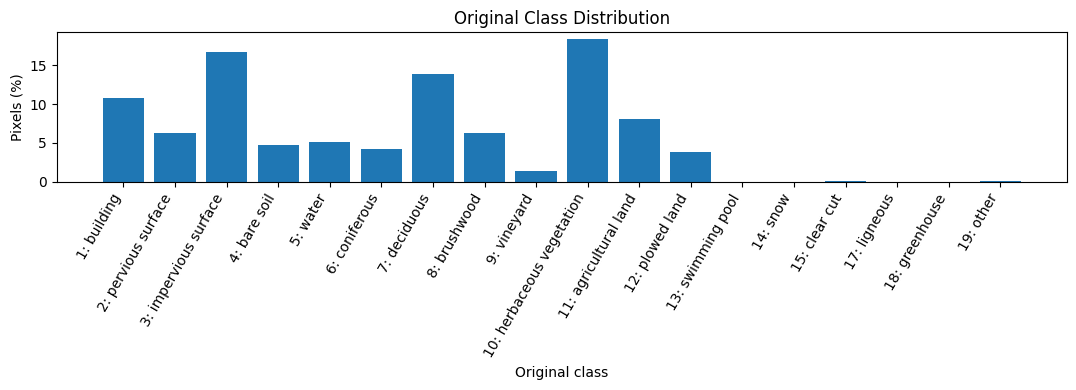

In [5]:
# plot original toy dataset class distribution by pixel frequency
import matplotlib.pyplot as plt

class_ids = sorted(pixel_counts)
percentages = [pixel_counts[class_id] / total_pixels * 100 for class_id in class_ids]
labels = [f"{class_id}: {class_names[class_id]}" for class_id in class_ids]

plt.figure(figsize=(11, 4))
plt.bar(labels, percentages)
plt.xticks(rotation=60, ha="right")
plt.xlabel("Original class")
plt.ylabel("Pixels (%)")
plt.title("Original Class Distribution")
plt.tight_layout()
plt.show()


In [6]:
# combine swimming pool, snow, clear cut, mixed, ligneous, greenhouse into "other" class
classes_to_combine = {9, 13, 14, 15, 17, 18, 19}
combined_other_id = 19

# merge small classes into "other" and update class names
combined_class_names = {
    class_id: class_name
    for class_id, class_name in class_names.items()
    if class_id not in classes_to_combine or class_id == combined_other_id
}
combined_class_names[combined_other_id] = "other"

# create mapping from original class IDs to combined class IDs
class_remap = {
    class_id: (combined_other_id if class_id in classes_to_combine else class_id)
    for class_id in class_names
}

# recount pixels for combined classes and sort by frequency and class name
combined_pixel_counts = Counter()
combined_masks_with_class = Counter()
combined_split_pixel_counts = defaultdict(Counter)

# apply class remapping to each mask and recount pixels for combined classes
for record in records:
    mask = np.array(Image.open(record["mask_path"]))
    remapped_mask = np.vectorize(class_remap.get)(mask)
    class_ids, counts = np.unique(remapped_mask, return_counts=True)
    for class_id, count in zip(class_ids.tolist(), counts.tolist()):
        combined_pixel_counts[class_id] += count
        combined_masks_with_class[class_id] += 1
        combined_split_pixel_counts[record["split"]][class_id] += count

combined_total_pixels = sum(combined_pixel_counts.values())

print(f"Combined classes present: {len(combined_pixel_counts)}")
print(f"Total labeled pixels: {combined_total_pixels:,}")
print("class_id  class_name             pixels        percent   masks")
for class_id, pixels in sorted(combined_pixel_counts.items(), key=lambda item: item[1], reverse=True):
    class_name = combined_class_names.get(class_id, "unknown")
    percent = pixels / combined_total_pixels * 100
    masks = combined_masks_with_class[class_id]
    print(f"{class_id:>8}  {class_name:<20}  {pixels:>12,}  {percent:>7.2f}%  {masks:>5}")


Combined classes present: 12
Total labeled pixels: 65,536,000
class_id  class_name             pixels        percent   masks
      10  herbaceous vegetation    11,995,203    18.30%    212
       3  impervious surface      10,957,832    16.72%    161
       7  deciduous                9,114,062    13.91%    192
       1  building                 7,097,375    10.83%    127
      11  agricultural land        5,334,674     8.14%     52
       8  brushwood                4,128,011     6.30%    160
       2  pervious surface         4,083,174     6.23%    127
       5  water                    3,373,713     5.15%     47
       4  bare soil                3,078,313     4.70%     34
       6  coniferous               2,793,777     4.26%     65
      12  plowed land              2,535,121     3.87%     20
      19  other                    1,044,745     1.59%     70


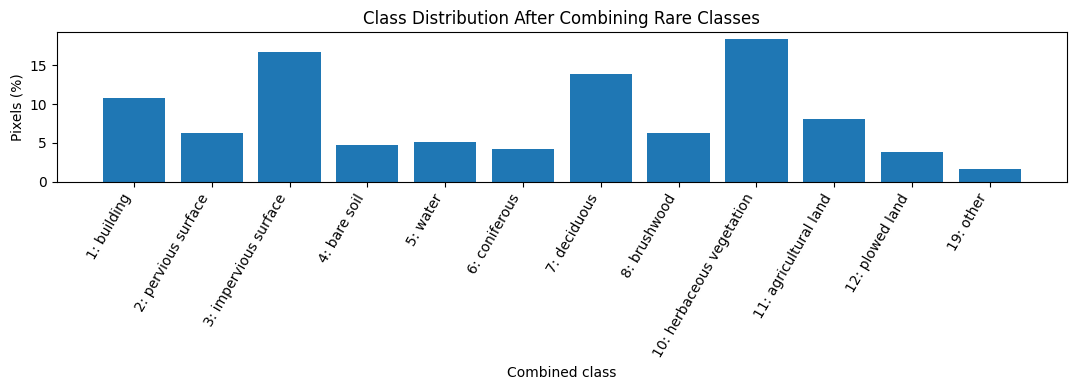

In [7]:
# plot combined distribution after class merge
combined_class_ids = sorted(combined_pixel_counts)
combined_percentages = [
    combined_pixel_counts[class_id] / combined_total_pixels * 100
    for class_id in combined_class_ids
]
combined_labels = [
    f"{class_id}: {combined_class_names[class_id]}"
    for class_id in combined_class_ids
]

plt.figure(figsize=(11, 4))
plt.bar(combined_labels, combined_percentages)
plt.xticks(rotation=60, ha="right")
plt.xlabel("Combined class")
plt.ylabel("Pixels (%)")
plt.title("Class Distribution After Combining Rare Classes")
plt.tight_layout()
plt.show()


### Consolidate into 5 Broad Classes

In [8]:
# # consolidate FLAIR classes into five broad groups
# grouped_class_names = {
#     1: "trees/bush",
#     2: "vegetation",
#     3: "soil/land",
#     4: "building/manmade",
#     5: "other",
# }

# group_source_classes = {
#     1: {6, 7, 8, 16, 17},  # coniferous, deciduous, brushwood, mixed, ligneous
#     2: {9, 10, 11},  # vineyard, herbaceous vegetation, agricultural land
#     3: {2, 4, 12},  # pervious surface, bare soil, plowed land
#     4: {1, 3, 13, 18},  # building, impervious surface, swimming pool, greenhouse
#     5: {5, 14, 15, 19},  # water, snow, clear cut, other
# }

# # create mapping from original class IDs to grouped class IDs
# grouped_class_remap = {
#     original_class_id: grouped_class_id
#     for grouped_class_id, original_class_ids in group_source_classes.items()
#     for original_class_id in original_class_ids
# }

# missing_grouped_classes = sorted(set(class_names) - set(grouped_class_remap))
# if missing_grouped_classes:
#     raise ValueError(f"Missing grouped mapping for class IDs: {missing_grouped_classes}")

# # recount pixels for grouped classes and sort by frequency and class name
# grouped_pixel_counts = Counter()
# grouped_masks_with_class = Counter()
# grouped_split_pixel_counts = defaultdict(Counter)

# # apply class remapping to each mask and recount pixels for grouped classes
# for record in records:
#     mask = np.array(Image.open(record["mask_path"]))
#     remapped_mask = np.vectorize(grouped_class_remap.get)(mask)
#     class_ids, counts = np.unique(remapped_mask, return_counts=True)
#     for class_id, count in zip(class_ids.tolist(), counts.tolist()):
#         grouped_pixel_counts[class_id] += count
#         grouped_masks_with_class[class_id] += 1
#         grouped_split_pixel_counts[record["split"]][class_id] += count

# grouped_total_pixels = sum(grouped_pixel_counts.values())

# print(f"Grouped classes present: {len(grouped_pixel_counts)}")
# print(f"Total labeled pixels: {grouped_total_pixels:,}")
# print("class_id  class_name             pixels        percent   masks")
# for class_id, pixels in sorted(grouped_pixel_counts.items(), key=lambda item: item[1], reverse=True):
#     class_name = grouped_class_names.get(class_id, "unknown")
#     percent = pixels / grouped_total_pixels * 100
#     masks = grouped_masks_with_class[class_id]
#     print(f"{class_id:>8}  {class_name:<20}  {pixels:>12,}  {percent:>7.2f}%  {masks:>5}")


In [9]:
# # plot grouped distribution after five-class consolidation
# grouped_class_ids = sorted(grouped_pixel_counts)
# grouped_percentages = [
#     grouped_pixel_counts[class_id] / grouped_total_pixels * 100
#     for class_id in grouped_class_ids
# ]
# grouped_labels = [
#     f"{class_id}: {grouped_class_names[class_id]}"
#     for class_id in grouped_class_ids
# ]

# plt.figure(figsize=(11, 4))
# plt.bar(grouped_labels, grouped_percentages)
# plt.xticks(rotation=45, ha="right")
# plt.xlabel("Grouped class")
# plt.ylabel("Pixels (%)")
# plt.title("Class Distribution After Five-Class Consolidation")
# plt.tight_layout()
# plt.show()


### Paper-Based 6 Class Mapping



In [10]:
# consolidate FLAIR classes into seven paper-aligned groups, with water separated
grouped_class_names = {
    1: "anthropized_no_veg",
    2: "natural_no_veg",
    3: "woody_veg",
    4: "agriculture",
    5: "herbaceous",
    6: "water",
}

group_source_classes = {
    1: {1, 2, 3, 13, 18},  # building, pervious, impervious, swimming pool, greenhouse
    2: {4, 14, 19},  # bare soil, snow, other
    3: {6, 7, 8, 15, 16, 17},  # coniferous, deciduous, brushwood, clear cut, mixed, ligneous
    4: {9, 11, 12},  # vineyard, agricultural land, plowed land
    5: {10},  # herbaceous vegetation
    6: {5},  # water
}

# create mapping from original class IDs to grouped class IDs
grouped_class_remap = {
    original_class_id: grouped_class_id
    for grouped_class_id, original_class_ids in group_source_classes.items()
    for original_class_id in original_class_ids
}

missing_grouped_classes = sorted(set(class_names) - set(grouped_class_remap))
if missing_grouped_classes:
    raise ValueError(f"Missing grouped mapping for class IDs: {missing_grouped_classes}")

# recount pixels for grouped classes and sort by frequency and class name
grouped_pixel_counts = Counter()
grouped_masks_with_class = Counter()
grouped_split_pixel_counts = defaultdict(Counter)

# apply class remapping to each mask and recount pixels for grouped classes
for record in records:
    mask = np.array(Image.open(record["mask_path"]))
    remapped_mask = np.vectorize(grouped_class_remap.get)(mask)
    class_ids, counts = np.unique(remapped_mask, return_counts=True)
    for class_id, count in zip(class_ids.tolist(), counts.tolist()):
        grouped_pixel_counts[class_id] += count
        grouped_masks_with_class[class_id] += 1
        grouped_split_pixel_counts[record["split"]][class_id] += count

grouped_total_pixels = sum(grouped_pixel_counts.values())

print(f"Grouped classes present: {len(grouped_pixel_counts)}")
print(f"Total labeled pixels: {grouped_total_pixels:,}")
print("class_id  class_name             pixels        percent   masks")
for class_id, pixels in sorted(grouped_pixel_counts.items(), key=lambda item: item[1], reverse=True):
    class_name = grouped_class_names.get(class_id, "unknown")
    percent = pixels / grouped_total_pixels * 100
    masks = grouped_masks_with_class[class_id]
    print(f"{class_id:>8}  {class_name:<20}  {pixels:>12,}  {percent:>7.2f}%  {masks:>5}")


Grouped classes present: 6
Total labeled pixels: 65,536,000
class_id  class_name             pixels        percent   masks
       1  anthropized_no_veg      22,172,061    33.83%    192
       3  woody_veg               16,075,554    24.53%    214
       5  herbaceous              11,995,203    18.30%    212
       4  agriculture              8,767,426    13.38%     72
       6  water                    3,373,713     5.15%     47
       2  natural_no_veg           3,152,043     4.81%     58


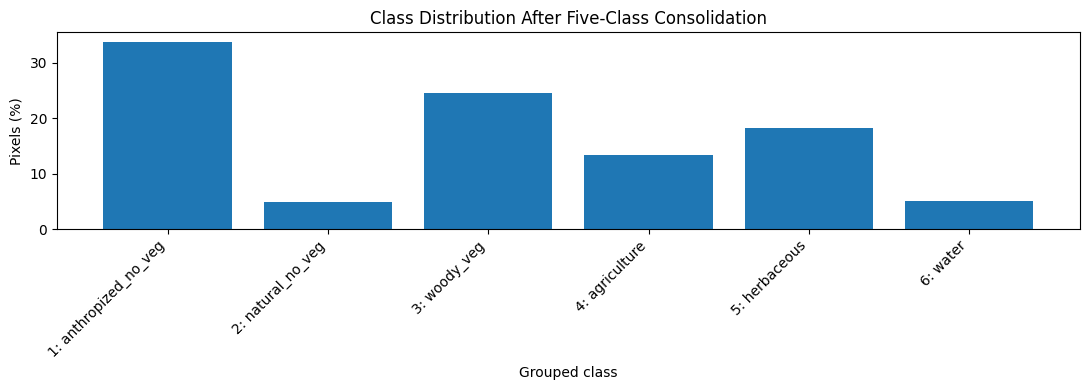

In [11]:
# plot grouped distribution after seven-class consolidation
grouped_class_ids = sorted(grouped_pixel_counts)
grouped_percentages = [
    grouped_pixel_counts[class_id] / grouped_total_pixels * 100
    for class_id in grouped_class_ids
]
grouped_labels = [
    f"{class_id}: {grouped_class_names[class_id]}"
    for class_id in grouped_class_ids
]

plt.figure(figsize=(11, 4))
plt.bar(grouped_labels, grouped_percentages)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Grouped class")
plt.ylabel("Pixels (%)")
plt.title("Class Distribution After Five-Class Consolidation")
plt.tight_layout()
plt.show()


## Refactor Splits into Larger Train + Val/Test

In [12]:
# create a new 80/10/10 split from all records, keeping train as large as possible
split_seed = 24788
split_targets = {"train": 200, "val": 25, "test": 25}
split_dir = repo_root / "data" / "processed" / "splits"
split_dir.mkdir(parents=True, exist_ok=True)

# store grouped class pixel counts for each mask once so split checks are quick
records_with_grouped_counts = []
for record in records:
    mask = np.array(Image.open(record["mask_path"]))
    remapped_mask = np.vectorize(grouped_class_remap.get)(mask)
    class_ids, counts = np.unique(remapped_mask, return_counts=True)
    grouped_counts = Counter(dict(zip(class_ids.tolist(), counts.tolist())))
    records_with_grouped_counts.append({**record, "grouped_counts": grouped_counts})

full_counts = Counter()
for record in records_with_grouped_counts:
    full_counts.update(record["grouped_counts"])
full_total = sum(full_counts.values())
full_distribution = {
    class_id: full_counts[class_id] / full_total
    for class_id in grouped_class_names
}

# try many fixed-size random splits and keep the one closest to the full pixel distribution
rng = np.random.default_rng(split_seed)
best_score = float("inf")
best_split_records = None

for _ in range(10000):
    shuffled_indices = rng.permutation(len(records_with_grouped_counts))
    start = 0
    candidate = {}
    for split, size in split_targets.items():
        split_indices = shuffled_indices[start:start + size]
        candidate[split] = [records_with_grouped_counts[index] for index in split_indices]
        start += size

    split_scores = []
    for split_records in candidate.values():
        split_counts = Counter()
        for record in split_records:
            split_counts.update(record["grouped_counts"])
        split_total = sum(split_counts.values())
        split_scores.append(sum(
            abs(split_counts[class_id] / split_total - full_distribution[class_id])
            for class_id in grouped_class_names
        ))

    score = max(split_scores)
    if score < best_score:
        best_score = score
        best_split_records = candidate

# write simple CSV manifests with repo-relative paths and the original split for traceability
for split, split_records in best_split_records.items():
    output_path = split_dir / f"{split}.csv"
    with output_path.open("w", newline="") as file:
        writer = csv.writer(file)
        writer.writerow(["image_path", "mask_path", "original_split"])
        for record in split_records:
            writer.writerow([
                record["image_path"].relative_to(repo_root),
                record["mask_path"].relative_to(repo_root),
                record["split"],
            ])

print(f"Wrote split CSVs to {split_dir.relative_to(repo_root)}")
for split, split_records in best_split_records.items():
    print(f"{split:>5}: {len(split_records)} samples")


Wrote split CSVs to data/processed/splits
train: 200 samples
  val: 25 samples
 test: 25 samples


In [13]:
# verify grouped class distribution across the new train/val/test split
print("split  samples  class_name             pixels        percent   delta")
for split, split_records in best_split_records.items():
    split_counts = Counter()
    for record in split_records:
        split_counts.update(record["grouped_counts"])
    split_total = sum(split_counts.values())

    for class_id in sorted(grouped_class_names):
        pixels = split_counts[class_id]
        percent = pixels / split_total * 100
        full_percent = full_distribution[class_id] * 100
        delta = percent - full_percent
        class_name = grouped_class_names[class_id]
        print(f"{split:<5}  {len(split_records):>7}  {class_name:<20}  {pixels:>12,}  {percent:>7.2f}%  {delta:>+6.2f}")
    print()


split  samples  class_name             pixels        percent   delta
train      200  anthropized_no_veg      17,593,769    33.56%   -0.27
train      200  natural_no_veg           2,476,929     4.72%   -0.09
train      200  woody_veg               12,796,594    24.41%   -0.12
train      200  agriculture              7,042,266    13.43%   +0.05
train      200  herbaceous               9,882,499    18.85%   +0.55
train      200  water                    2,636,743     5.03%   -0.12

val         25  anthropized_no_veg       2,344,976    35.78%   +1.95
val         25  natural_no_veg             404,160     6.17%   +1.36
val         25  woody_veg                1,622,932    24.76%   +0.23
val         25  agriculture                842,288    12.85%   -0.53
val         25  herbaceous               1,046,572    15.97%   -2.33
val         25  water                      292,672     4.47%   -0.68

test        25  anthropized_no_veg       2,233,316    34.08%   +0.25
test        25  natural_no_veg  

In [14]:
# write reusable class map and training split statistics for src/data.py
processed_dir = repo_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

class_map = {
    "num_classes": len(grouped_class_names),
    "ignore_index": 255,
    "class_names": {
        str(class_id - 1): class_name
        for class_id, class_name in grouped_class_names.items()
    },
    "source_to_target": {
        str(source_class_id): grouped_class_id - 1
        for source_class_id, grouped_class_id in sorted(grouped_class_remap.items())
    },
}

train_counts = Counter()
for record in best_split_records["train"]:
    train_counts.update(record["grouped_counts"])
train_total = sum(train_counts.values())

train_stats = {
    "num_samples": len(best_split_records["train"]),
    "num_pixels": train_total,
    "class_pixel_counts": {
        str(class_id - 1): train_counts[class_id]
        for class_id in sorted(grouped_class_names)
    },
    "class_pixel_percent": {
        str(class_id - 1): train_counts[class_id] / train_total * 100
        for class_id in sorted(grouped_class_names)
    },
}

with (processed_dir / "class_map.json").open("w") as file:
    json.dump(class_map, file, indent=2)

with (processed_dir / "train_stats.json").open("w") as file:
    json.dump(train_stats, file, indent=2)

print(f"Wrote {processed_dir / 'class_map.json'}")
print(f"Wrote {processed_dir / 'train_stats.json'}")


Wrote /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation/data/processed/class_map.json
Wrote /content/drive/MyDrive/Deep Learning Project/DLE-Flair-Segmentation/data/processed/train_stats.json
